# IPL Match & Ball-by-Ball Data Analysis

## Objective
This project analyzes IPL match and ball-by-ball data to uncover insights about:
- Team performance
- Player performance
- Batting trends
- Bowling trends
- Match outcomes

## Tools Used
- Python
- Pandas
- NumPy
- Matplotlib
- Seaborn

In [6]:
import pandas as pd
import numpy as np
import matplotlib.pylab as plt
import seaborn as sns
matches=pd.read_csv("../data/matches.csv")
deliveries=pd.read_csv("../data/deliveries.csv")
print(deliveries.head(5))
print(matches.head(5))

   season_id  match_id       batter   bowler  non_striker  team_batting  \
0       2008    335982   SC Ganguly  P Kumar  BB McCullum             6   
1       2008    335982  BB McCullum  P Kumar   SC Ganguly             6   
2       2008    335982  BB McCullum  P Kumar   SC Ganguly             6   
3       2008    335982  BB McCullum  P Kumar   SC Ganguly             6   
4       2008    335982  BB McCullum  P Kumar   SC Ganguly             6   

   team_bowling  over_number  ball_number  batter_runs  ...  is_bye  \
0             1            0            0            0  ...   False   
1             1            0            1            0  ...   False   
2             1            0            2            0  ...   False   
3             1            0            3            0  ...   False   
4             1            0            4            0  ...   False   

   is_penalty wide_ball_runs no_ball_runs leg_bye_runs bye_runs  penalty_runs  \
0       False              0            0

In [7]:
print(matches.info())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1212 entries, 0 to 1211
Data columns (total 23 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   match_id         1212 non-null   int64  
 1   season_id        1212 non-null   int64  
 2   balls_per_over   1212 non-null   int64  
 3   city             1161 non-null   object 
 4   match_date       1212 non-null   object 
 5   event_name       1212 non-null   object 
 6   match_number     1142 non-null   float64
 7   gender           1212 non-null   object 
 8   match_type       1212 non-null   object 
 9   format           1212 non-null   object 
 10  overs            1212 non-null   int64  
 11  season           1212 non-null   object 
 12  team_type        1212 non-null   object 
 13  venue            1212 non-null   object 
 14  toss_winner      1212 non-null   int64  
 15  team1            1212 non-null   int64  
 16  team2            1212 non-null   int64  
 17  toss_decision 

In [8]:
print(deliveries.info())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 288226 entries, 0 to 288225
Data columns (total 30 columns):
 #   Column             Non-Null Count   Dtype 
---  ------             --------------   ----- 
 0   season_id          288226 non-null  int64 
 1   match_id           288226 non-null  int64 
 2   batter             288226 non-null  object
 3   bowler             288226 non-null  object
 4   non_striker        288226 non-null  object
 5   team_batting       288226 non-null  int64 
 6   team_bowling       288226 non-null  int64 
 7   over_number        288226 non-null  int64 
 8   ball_number        288226 non-null  int64 
 9   batter_runs        288226 non-null  int64 
 10  extras             288226 non-null  int64 
 11  total_runs         288226 non-null  int64 
 12  batsman_type       287987 non-null  object
 13  bowler_type        287887 non-null  object
 14  player_out         14340 non-null   object
 15  fielders_involved  14340 non-null   object
 16  is_wicket          2

In [9]:
print(matches.shape)
print(deliveries.shape)
print(matches.columns)
print(deliveries.columns)

(1212, 23)
(288226, 30)
Index(['match_id', 'season_id', 'balls_per_over', 'city', 'match_date',
       'event_name', 'match_number', 'gender', 'match_type', 'format', 'overs',
       'season', 'team_type', 'venue', 'toss_winner', 'team1', 'team2',
       'toss_decision', 'match_winner', 'win_by_runs', 'win_by_wickets',
       'result', 'player_of_match'],
      dtype='object')
Index(['season_id', 'match_id', 'batter', 'bowler', 'non_striker',
       'team_batting', 'team_bowling', 'over_number', 'ball_number',
       'batter_runs', 'extras', 'total_runs', 'batsman_type', 'bowler_type',
       'player_out', 'fielders_involved', 'is_wicket', 'is_wide_ball',
       'is_no_ball', 'is_leg_bye', 'is_bye', 'is_penalty', 'wide_ball_runs',
       'no_ball_runs', 'leg_bye_runs', 'bye_runs', 'penalty_runs',
       'wicket_kind', 'is_super_over', 'innings'],
      dtype='object')


## checking the missing values


In [13]:
matches.isnull().sum()
deliveries.isnull().sum()

season_id                 0
match_id                  0
batter                    0
bowler                    0
non_striker               0
team_batting              0
team_bowling              0
over_number               0
ball_number               0
batter_runs               0
extras                    0
total_runs                0
batsman_type            239
bowler_type             339
player_out           273886
fielders_involved    273886
is_wicket                 0
is_wide_ball              0
is_no_ball                0
is_leg_bye                0
is_bye                    0
is_penalty                0
wide_ball_runs            0
no_ball_runs              0
leg_bye_runs              0
bye_runs                  0
penalty_runs              0
wicket_kind          273886
is_super_over             0
innings                   0
dtype: int64

In [14]:
matches.duplicated().sum()
deliveries.duplicated().sum()

np.int64(0)

### Data Cleaning Summary

- Checked missing values and duplicate records.
- Missing values in `win_by_runs` and `win_by_wickets` were expected because a match can be won either by runs or wickets.
- Missing values in `player_out`, `fielders_involved`, and `wicket_kind` were expected because most deliveries do not result in a wicket.
- No major data quality issues affecting the analysis were found.

In [17]:
top_batters=(deliveries.groupby('batter')['batter_runs'].sum().sort_values(ascending=False).head(10))
print(top_batters)

batter
V Kohli           9050
RG Sharma         7185
S Dhawan          6769
DA Warner         6567
KL Rahul          5668
SK Raina          5536
MS Dhoni          5439
AM Rahane         5194
AB de Villiers    5181
SV Samson         5008
Name: batter_runs, dtype: int64


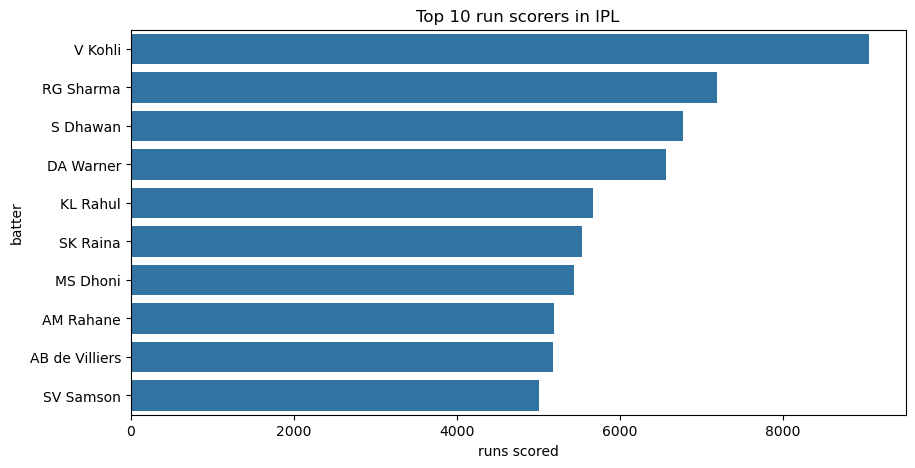

In [18]:
plt.figure(figsize=(10,5))
sns.barplot(x=top_batters.values,y=top_batters.index)
plt.title("Top 10 run scorers in IPL")
plt.xlabel("runs scored")
plt.ylabel("batter")
plt.show()

### Insight

- Virat Kohli is the highest run scorer in IPL history with more than 9000 runs.
- Consistent performance across multiple seasons has helped him maintain the top position.
- The top 10 run scorers represent some of the most successful batters in IPL history.

## Top 10 batters with most sixes

In [19]:
sixes=(deliveries[deliveries['batter_runs']==6].groupby('batter').size().sort_values(ascending=False).head(10))
print(sixes)

batter
CH Gayle          359
RG Sharma         311
V Kohli           307
MS Dhoni          264
AB de Villiers    253
DA Warner         236
SV Samson         234
KL Rahul          232
KA Pollard        224
AD Russell        223
dtype: int64


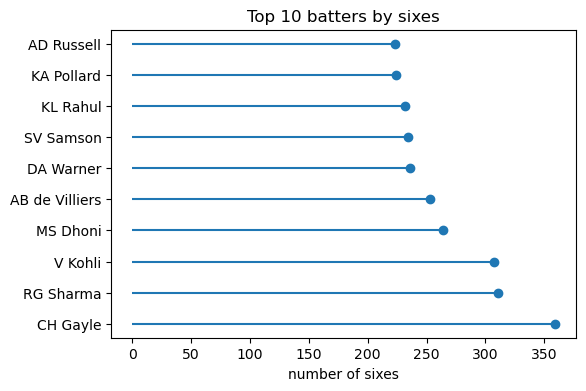

In [20]:
plt.figure(figsize=(6,4))
plt.hlines(y=sixes.index,xmin=0,xmax=sixes.values)
plt.plot(sixes.values,sixes.index,"o")
plt.title("Top 10 batters by sixes")
plt.xlabel("number of sixes")
plt.show()

### Insight

- Chris Gayle leads the six-hitting chart, demonstrating his aggressive batting style.
- Power hitters occupy most of the top positions.
- Six-hitting ability plays a crucial role in T20 match-winning performances.

## Most fours

In [21]:
fours = (
    deliveries[deliveries['batter_runs'] == 4]
    .groupby('batter')
    .size()
    .sort_values(ascending=False)
    .head(10)
)

print(fours)

batter
V Kohli       816
S Dhawan      768
DA Warner     663
RG Sharma     653
AM Rahane     523
SK Raina      506
KL Rahul      495
G Gambhir     492
RV Uthappa    481
SA Yadav      472
dtype: int64


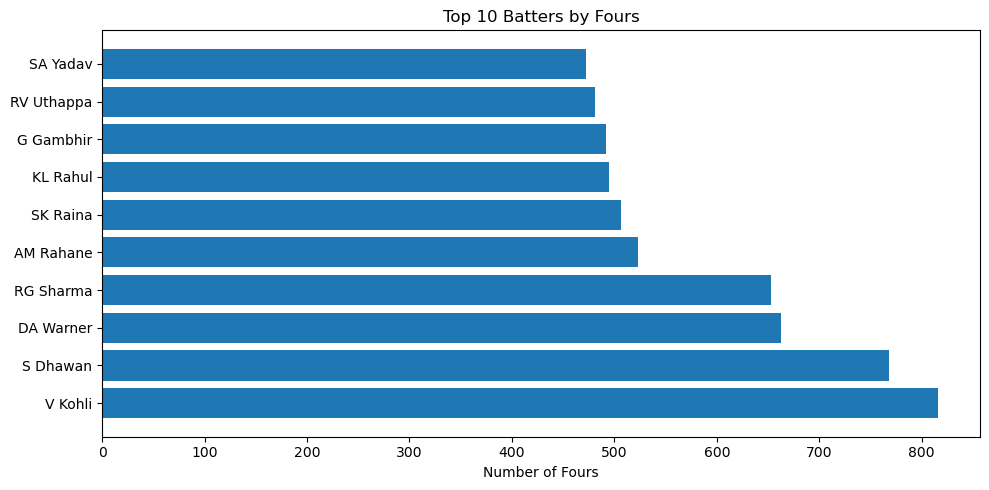

In [22]:
plt.figure(figsize=(10,5))

plt.barh(
    fours.index,
    fours.values
)

plt.title("Top 10 Batters by Fours")
plt.xlabel("Number of Fours")

plt.tight_layout()

plt.show()

### Insight

- The players with the most fours are generally consistent run scorers.
- Four-hitting reflects batting technique and placement rather than pure power.
- Batters who score heavily through fours often maintain higher consistency.

## Top wicket takers

In [23]:
wickets = (
    deliveries[deliveries['is_wicket'] == 1]
    .groupby('bowler')
    .size()
    .sort_values(ascending=False)
    .head(10)
)

print(wickets)

bowler
YS Chahal     237
B Kumar       231
SP Narine     221
DJ Bravo      207
JJ Bumrah     206
R Ashwin      205
PP Chawla     201
SL Malinga    188
RA Jadeja     186
A Mishra      183
dtype: int64


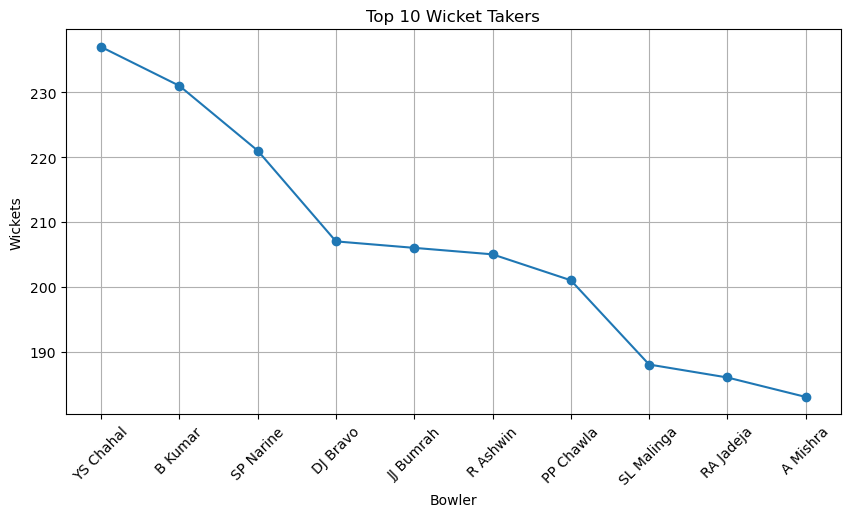

In [24]:
plt.figure(figsize=(10,5))

plt.plot(
    wickets.index,
    wickets.values,
    marker='o'
)

plt.title("Top 10 Wicket Takers")
plt.xlabel("Bowler")
plt.ylabel("Wickets")

plt.xticks(rotation=45)

plt.grid()

plt.show()

### Insight

- Yuzvendra Chahal is the leading wicket-taker in the dataset.
- His ability to take wickets regularly has made him one of the most successful IPL bowlers.

## Toss decision analysis

In [39]:
toss_decision = matches['toss_decision'].value_counts()

print(toss_decision)

toss_decision
field    800
bat      412
Name: count, dtype: int64


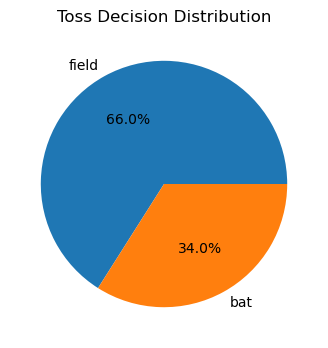

In [41]:
plt.figure(figsize=(4,4))

plt.pie(
    toss_decision.values,
    labels=toss_decision.index,
    autopct='%1.1f%%'
)

plt.title("Toss Decision Distribution")

plt.show()

## Insight:
 Teams prefer to field after winning the toss.

## Toss impact analysis

In [42]:
toss_match_win = (
    matches['toss_winner']
    == matches['match_winner']
).sum()

total_matches = len(matches)

percentage = (
    toss_match_win
    / total_matches
) * 100

print("Toss Winner also won Match:", round(percentage,2), "%")

Toss Winner also won Match: 51.65 %


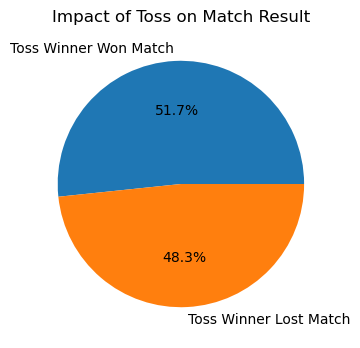

In [45]:
won = toss_match_win

lost = total_matches - toss_match_win

plt.figure(figsize=(4,4))

plt.pie(
    [won, lost],
    labels=[
        "Toss Winner Won Match",
        "Toss Winner Lost Match"
    ],
    autopct='%1.1f%%'
)

plt.title("Impact of Toss on Match Result")

plt.show()

 ## Insight:
 Toss winners also won the match in 51.65% of games.

## Matches per season

In [46]:
matches_per_season = (
    matches.groupby('season')
    .size()
)

print(matches_per_season)

season
2008       58
2009       57
2010       60
2011       73
2012       74
2013       76
2014       60
2015       59
2016       60
2017       59
2018       60
2019       60
2020/21    60
2021       60
2022       74
2023       74
2024       71
2025       74
2026       43
dtype: int64


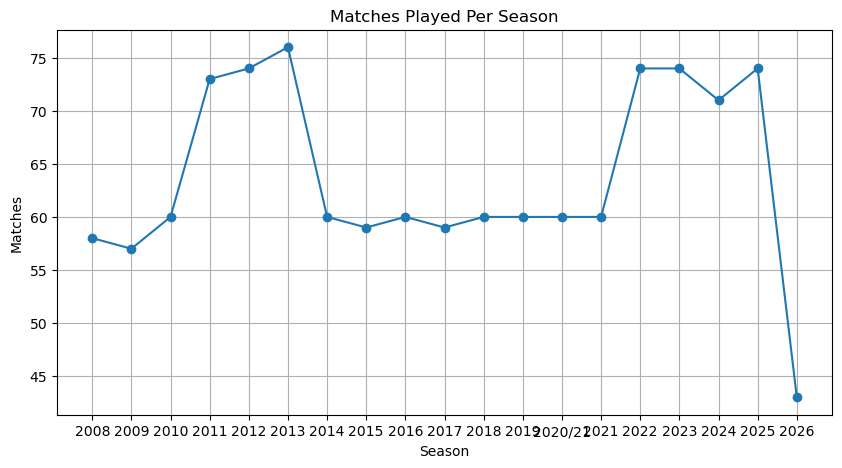

In [47]:
plt.figure(figsize=(10,5))

plt.plot(
    matches_per_season.index,
    matches_per_season.values,
    marker='o'
)

plt.title("Matches Played Per Season")
plt.xlabel("Season")
plt.ylabel("Matches")

plt.grid()

plt.show()

## Insight:
 Season 2013 recorded the highest number of matches (76).

## Top venues

In [48]:
venues = (
    matches['venue']
    .value_counts()
    .head(10)
)

print(venues)

venue
Eden Gardens                                 77
Wankhede Stadium                             73
M Chinnaswamy Stadium                        65
Feroz Shah Kotla                             60
Wankhede Stadium, Mumbai                     57
Rajiv Gandhi International Stadium, Uppal    49
MA Chidambaram Stadium, Chepauk              48
Sawai Mansingh Stadium                       47
Dubai International Cricket Stadium          46
MA Chidambaram Stadium, Chepauk, Chennai     38
Name: count, dtype: int64


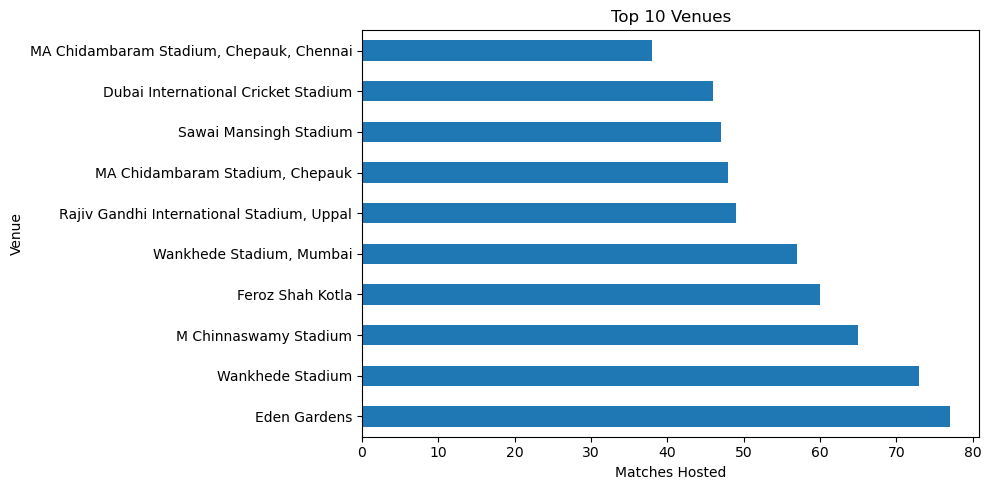

In [49]:
plt.figure(figsize=(10,5))

venues.plot(kind='barh')

plt.title("Top 10 Venues")
plt.xlabel("Matches Hosted")
plt.ylabel("Venue")

plt.tight_layout()

plt.show()

## Insights:
 Eden Gardens hosted the highest number of IPL matches (77).

## Win method analysis

In [51]:
wins_by_runs = (matches['win_by_runs'] > 0).sum()

wins_by_wickets = (matches['win_by_wickets'] > 0).sum()

print("Runs:", wins_by_runs)
print("Wickets:", wins_by_wickets)

Runs: 546
Wickets: 641


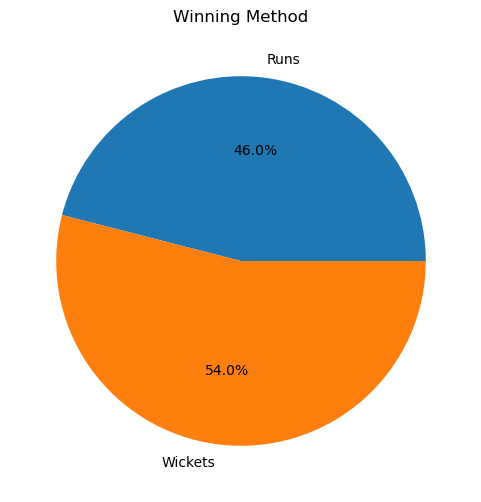

In [52]:
plt.figure(figsize=(6,6))

plt.pie(
    [wins_by_runs, wins_by_wickets],
    labels=["Runs", "Wickets"],
    autopct='%1.1f%%'
)

plt.title("Winning Method")

plt.show()

  ## Inshights
  More matches were won while chasing (by wickets) than defending a target.